# Analysis of embeddings

First, validation that document embeddings capture expected relationships between texts/periods/nations/etc. Then, results of the generative experiments.

In [1]:
import altair as alt
import ast
import glob
from   itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from   scipy import stats
import seaborn as sns
import umap

embeddings_dir = '../embeddings/human'
metadata_file = '../metadata/CONLIT_META_PLUS.csv'

use_all = False # all embeddings, or just the book-wise means?
models = ['gpt-5', 'gpt-5-mini', 'gpt-5-nano', 'gpt-4.1', 'gpt-3.5-turbo']

# big interactive charts!
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

## Load data

In [2]:
# read metadata
meta = pd.read_csv(metadata_file, index_col='ID')
prize_renames = {
    'NationalBookAwards':'NBA',
    "GovernerGeneral's":"GGBooks",
    "ManBooker":"Booker",
    'TheManBookerPrize':'Booker', 
    'ScotiabankGillerPrize':'Giller',
    'GovernorGeneralLiteraryAwardforfiction':'GGBooks',
    'PEN/FaulknerAwardforFiction':'PEN/Faulkner',
    'TheNationalBookAwards':'NBA'
}
meta.Prize = meta.Prize.replace(prize_renames) # make prize names consistent
# add missing metadata
meta.loc['Charlotte Brontë - Claire Harman.txt','Genre'] = 'BIO'
meta.loc['Charlotte Brontë - Claire Harman.txt','Category'] = 'NON'
meta.loc['Charlotte Brontë - Claire Harman.txt','Pubdate'] = 2016
meta.loc['Ma’am Darling - Craig Brown.txt','Genre'] = 'BIO'
meta.loc['Ma’am Darling - Craig Brown.txt','Category'] = 'NON'
meta.loc['Ma’am Darling - Craig Brown.txt','Pubdate'] = 2017
meta.loc['2001_Martel,Yann_LifeofPi_BS.txt', ['Author_First_Reviewed', 'Author_Last_Reviewed']] = ['Yann', 'Martel']

In [3]:
# function to load an embedding file to pandas
def read_embedding(fileid, embeddings_dir=embeddings_dir):
    '''Takes a fileid (which is both an id and the filename).
    Loads embeddings and coverts embedding strings to numpy arrays.
    Returns a dataframe indexed to id and chunk sequence.'''
    df = pd.read_csv(
        os.path.join(embeddings_dir, fileid), 
        sep='\t',
        converters={'embed': ast.literal_eval}
    )
    df['ID'] = fileid
    df['embed'] = df['embed'].apply(np.array)
    df.set_index(['ID','seq'], inplace=True)
    return df

# function to load many embeddings to a single dataframe
def load_embeddings(textids, embeddings_dir=embeddings_dir):
    '''Takes a list of IDs (which are also filenames).
    Reads embeddings from each file.
    Returns a single dataframe of all indicated embeddings.'''
    dataframes = [read_embedding(textid, embeddings_dir=embeddings_dir) for textid in textids]
    return pd.concat(dataframes)

# function to calculate average embeddings per book
def weighted_mean_embedding(df):
    '''Takes a Pandas df of embeddings and weights, as for chunks of a volume.
    Calculates the weighted average of the embeddings and normalizes the result.
    Returns the resulting normed average embedding.'''
    result = np.average(df['embed'], weights=df['length'])
    return(result/np.linalg.norm(result))

In [4]:
# calculate means for new embeddings, then save for direct loading later
# skip if not recalculating
#for model in models:
#    embeddings_dir = f'../embeddings/basic_prompt/{model}'
#    embedding_files = glob.glob(os.path.join(embeddings_dir, '*')) 
#    embedding_files = [os.path.basename(path) for path in embedding_files]
#    emb = load_embeddings(embedding_files, embeddings_dir=embeddings_dir)
#    # calculate chunk lengths
#    emb['length'] = emb['end_token']-emb['start_token']
#    # calculate average embeddings over all full chunks per book
#    emb_mean = emb.loc[emb['start_token']>0].groupby('ID').apply(weighted_mean_embedding)
#    # write out average embeddings
#    with open(f'../results/emb_gen_{model}_mean.pickle', 'wb') as f:
#        pickle.dump(emb_mean, f)

In [5]:
%%time
# load embeddings

if use_all: # all embeddings (not fast)
    embedding_files = glob.glob(os.path.join(embeddings_dir, '*')) 
    embedding_files = [os.path.basename(path) for path in embedding_files]
    emb = load_embeddings(embedding_files)
    # calculate chunk lengths
    emb['length'] = emb['end_token']-emb['start_token']
    # calculate average embeddings over all full chunks per book
    emb_mean = emb.loc[emb['start_token']>0].groupby('ID').apply(weighted_mean_embedding)
    # write out average embeddings
    with open('../results/emb_mean.pickle', 'wb') as f:
        pickle.dump(emb_mean, f)

    # load embeddings of generated chapters
    emb_gen = load_embeddings([f'request-pw-gpt-5-{i}.tsv' for i in range(100)], '../embeddings/complex_prompt/gpt-5')
    # calculate chunk lengths
    emb_gen['length'] = emb_gen['end_token']-emb_gen['start_token']
    # average embeddings (not needed, b/c no multi-chunk chpaters, but still)
    emb_gen_mean = emb_gen.loc[emb_gen['start_token']>0].groupby('ID').apply(weighted_mean_embedding)
    # write out average embeddings
    with open('../results/emb_gen_pw_mean.pickle', 'wb') as f:
        pickle.dump(emb_gen_mean, f)

    # load embeddings and calulate means for new generations
    for genre in ['sf', 'my']:
        emb_gen = load_embeddings([f'request-{genre}-gpt-5-{i}.tsv' for i in range(100)], '../embeddings/complex_prompt/gpt-5')
        # calculate chunk lengths
        emb_gen['length'] = emb_gen['end_token']-emb_gen['start_token']
        # average embeddings (not needed, b/c no multi-chunk chapters, but still)
        emb_gen_mean = emb_gen.loc[emb_gen['start_token']>0].groupby('ID').apply(weighted_mean_embedding)
        # write out average embeddings
        with open(f'../results/emb_gen_{genre}_mean.pickle', 'wb') as f:
            pickle.dump(emb_gen_mean, f)

else:
    with open('../results/emb_mean.pickle', 'rb') as f:
        emb_mean = pickle.load(f)
    with open('../results/emb_gen_pw_mean.pickle', 'rb') as f:
        emb_gen_mean = pickle.load(f)
        emb_gen_mean = emb_gen_mean.sort_index(key=lambda x: x.str.replace('.tsv', '').astype(int))
        emb_gen_mean.index = ['pw-'+i for i in emb_gen_mean.index] 
    with open('../results/emb_gen_sf_mean.pickle', 'rb') as f:
        emb_gen_sf_mean = pickle.load(f)
        emb_gen_sf_mean = emb_gen_sf_mean.sort_index(key=lambda x: x.str.replace('.tsv', '').astype(int))
        emb_gen_sf_mean.index = ['sf-'+i for i in emb_gen_sf_mean.index] 
    with open('../results/emb_gen_my_mean.pickle', 'rb') as f:
        emb_gen_my_mean = pickle.load(f)
        emb_gen_my_mean = emb_gen_my_mean.sort_index(key=lambda x: x.str.replace('.tsv', '').astype(int))
        emb_gen_my_mean.index = ['my-'+i for i in emb_gen_my_mean.index] 
    emb_gen_model_means = {}
    for model in models:
        embeddings_dir = f'../embeddings/basic_prompt/{model}'
        embedding_files = glob.glob(os.path.join(embeddings_dir, '*')) 
        indices = [os.path.basename(path) for path in embedding_files]
        with open(f'../results/emb_gen_{model}_mean.pickle', 'rb') as f:
            data = pickle.load(f)
            data.index = indices 
        emb_gen_model_means[model] = data

CPU times: user 38.6 ms, sys: 65.5 ms, total: 104 ms
Wall time: 213 ms


In [6]:
# "Pubdate"s for generations
# prize noms
year_list = list(range(2005,2017))
year_list.append(np.nan)
year_list.append(np.nan)
pubdates = []
for year in year_list:
    for _ in range(100):
        pubdates.append(year)

# genres
genre_year_list = list(range(2010,2017))
genre_year_list.append(np.nan)
genre_year_list.append(np.nan)
genre_pubdates = []
for year in genre_year_list:
    for _ in range(50):
        genre_pubdates.append(year)

## Visualize

UMAP reducer fitted to real books only. Fitted reducer then used to map generated texts.

In [7]:
# reduce dimensions
reducer = umap.UMAP()
X = reducer.fit_transform(np.stack(emb_mean.values))

In [8]:
# gather data for convenience
plot_data = pd.DataFrame(
    data=X,
    columns=['x','y'],
    index=emb_mean.index
).join(meta)
plot_data['Prompt'] = 'Human'
plot_data['Model'] = 'Human'

In [9]:
# reduce generations and add a few metadata facets
# NB. we do not fit to generated data; reduction is a map to human books only
X_gen = reducer.transform(np.stack(emb_gen_mean.values))
X_gen_sf = reducer.transform(np.stack(emb_gen_sf_mean.values))
X_gen_my = reducer.transform(np.stack(emb_gen_my_mean.values))

In [10]:
plot_data_gen = pd.DataFrame(
    data=X_gen,
    columns=['x','y'],
    index=emb_gen_mean.index
)
plot_data_gen['Category'] = 'FIC'
plot_data_gen['Genre'] = 'PW-AI'
plot_data_gen['Prize'] = 'AI'
plot_data_gen['Pubdate'] = pubdates
plot_data_gen['Language'] = 'English'
plot_data_gen['Author_First_Reviewed'] = 'GPT-5'
plot_data_gen['Author_Last_Reviewed'] = 'OpenAI'
plot_data_gen['Work_Title'] = list(range(1400))
plot_data_gen['Prompt'] = 'Complex'
plot_data_gen['Model'] = 'GPT-5'

plot_data_gen_sf = pd.DataFrame(
    data=X_gen_sf,
    columns=['x','y'],
    index=emb_gen_sf_mean.index
)
plot_data_gen_sf['Category'] = 'FIC'
plot_data_gen_sf['Genre'] = 'SF-AI'
plot_data_gen_sf['Prize'] = np.nan
plot_data_gen_sf['Pubdate'] = genre_pubdates
plot_data_gen_sf['Language'] = 'English'
plot_data_gen_sf['Author_First_Reviewed'] = 'GPT-5'
plot_data_gen_sf['Author_Last_Reviewed'] = 'OpenAI'
plot_data_gen_sf['Work_Title'] = list(range(450))
plot_data_gen_sf['Prompt'] = 'Complex'
plot_data_gen_sf['Model'] = 'GPT-5'

plot_data_gen_my = pd.DataFrame(
    data=X_gen_my,
    columns=['x','y'],
    index=emb_gen_my_mean.index
)
plot_data_gen_my['Category'] = 'FIC'
plot_data_gen_my['Genre'] = 'MY-AI'
plot_data_gen_my['Prize'] = np.nan
plot_data_gen_my['Pubdate'] = genre_pubdates
plot_data_gen_my['Language'] = 'English'
plot_data_gen_my['Author_First_Reviewed'] = 'GPT-5'
plot_data_gen_my['Author_Last_Reviewed'] = 'OpenAI'
plot_data_gen_my['Work_Title'] = list(range(450))
plot_data_gen_my['Prompt'] = 'Complex'
plot_data_gen_my['Model'] = 'GPT-5'

plot_data = pd.concat([plot_data, plot_data_gen, plot_data_gen_sf, plot_data_gen_my])

In [11]:
X_gen_models = {}
for model in models:
    df = pd.DataFrame(
        reducer.transform(np.stack(emb_gen_model_means[model].values)),
        columns=['x','y'],
        index=emb_gen_model_means[model].index
    )
    metadata = emb_gen_model_means[model].index.str.rstrip('.tsv').str.split('-')
    df['Category'] = 'FIC'
    df['Genre'] = [f'{str.upper(metadata[i][1])}-AI' for i in range(len(metadata))]
    df['Prize'] = ['AI' if metadata[i][1]=='pw' else np.nan for i in range(len(metadata))]
    df['Pubdate'] = np.nan
    df['Language'] = 'English'
    df['Author_First_Reviewed'] = [f'GPT-{metadata[i][3]}' \
                                   if len(metadata)==4 \
                                   else f'GPT-{'-'.join(metadata[i][3:-1])}' \
                                   for i in range(len(metadata))]
    df['Author_Last_Reviewed'] = 'OpenAI'
    df['Work_Title'] = [metadata[i][-1] for i in range(len(metadata))]
    df['Prompt'] = 'Basic'
    df['Model'] = df['Author_First_Reviewed']
    X_gen_models[model] = df

In [12]:
plot_data_models = pd.concat([X_gen_models[model] for model in models])
plot_data = pd.concat([plot_data, plot_data_models])
meta_all = plot_data

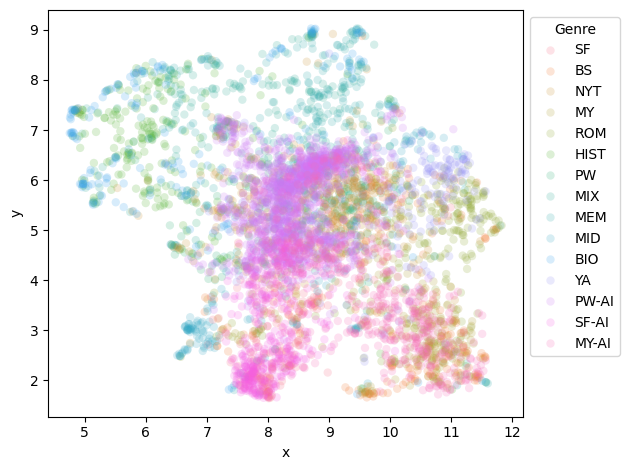

In [13]:
# static vis, all
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[plot_data['Prompt']!='Basic'],
    hue='Genre',
    alpha=0.2,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_by_genre_with_gen.png', dpi=300)

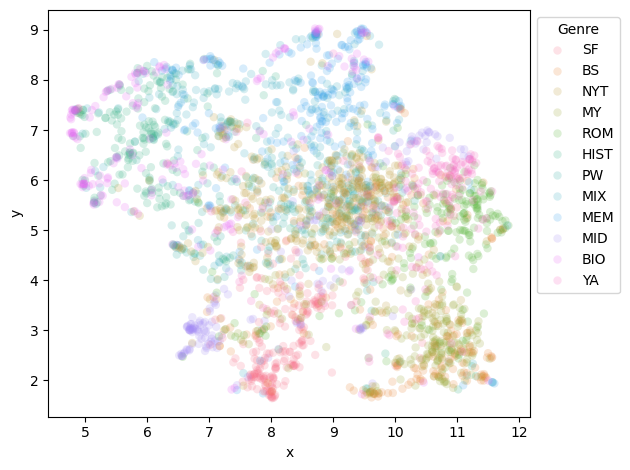

In [14]:
# static vis, all *except* AI
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[plot_data['Prompt']=='Human'],
    hue='Genre',
    alpha=0.2,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_by_genre_without_gen.png', dpi=300)

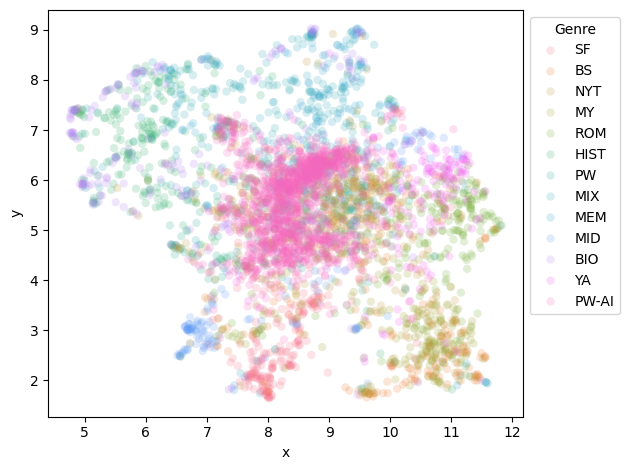

In [15]:
# static vis, all human and just PW-AI
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[
        (plot_data['Prompt']=='Human') |
        ((plot_data['Prompt']=='Complex') &
         (plot_data['Genre']=='PW-AI'))
        ],
    hue='Genre',
    alpha=0.2,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_by_genre_and_pwai.png', dpi=300)

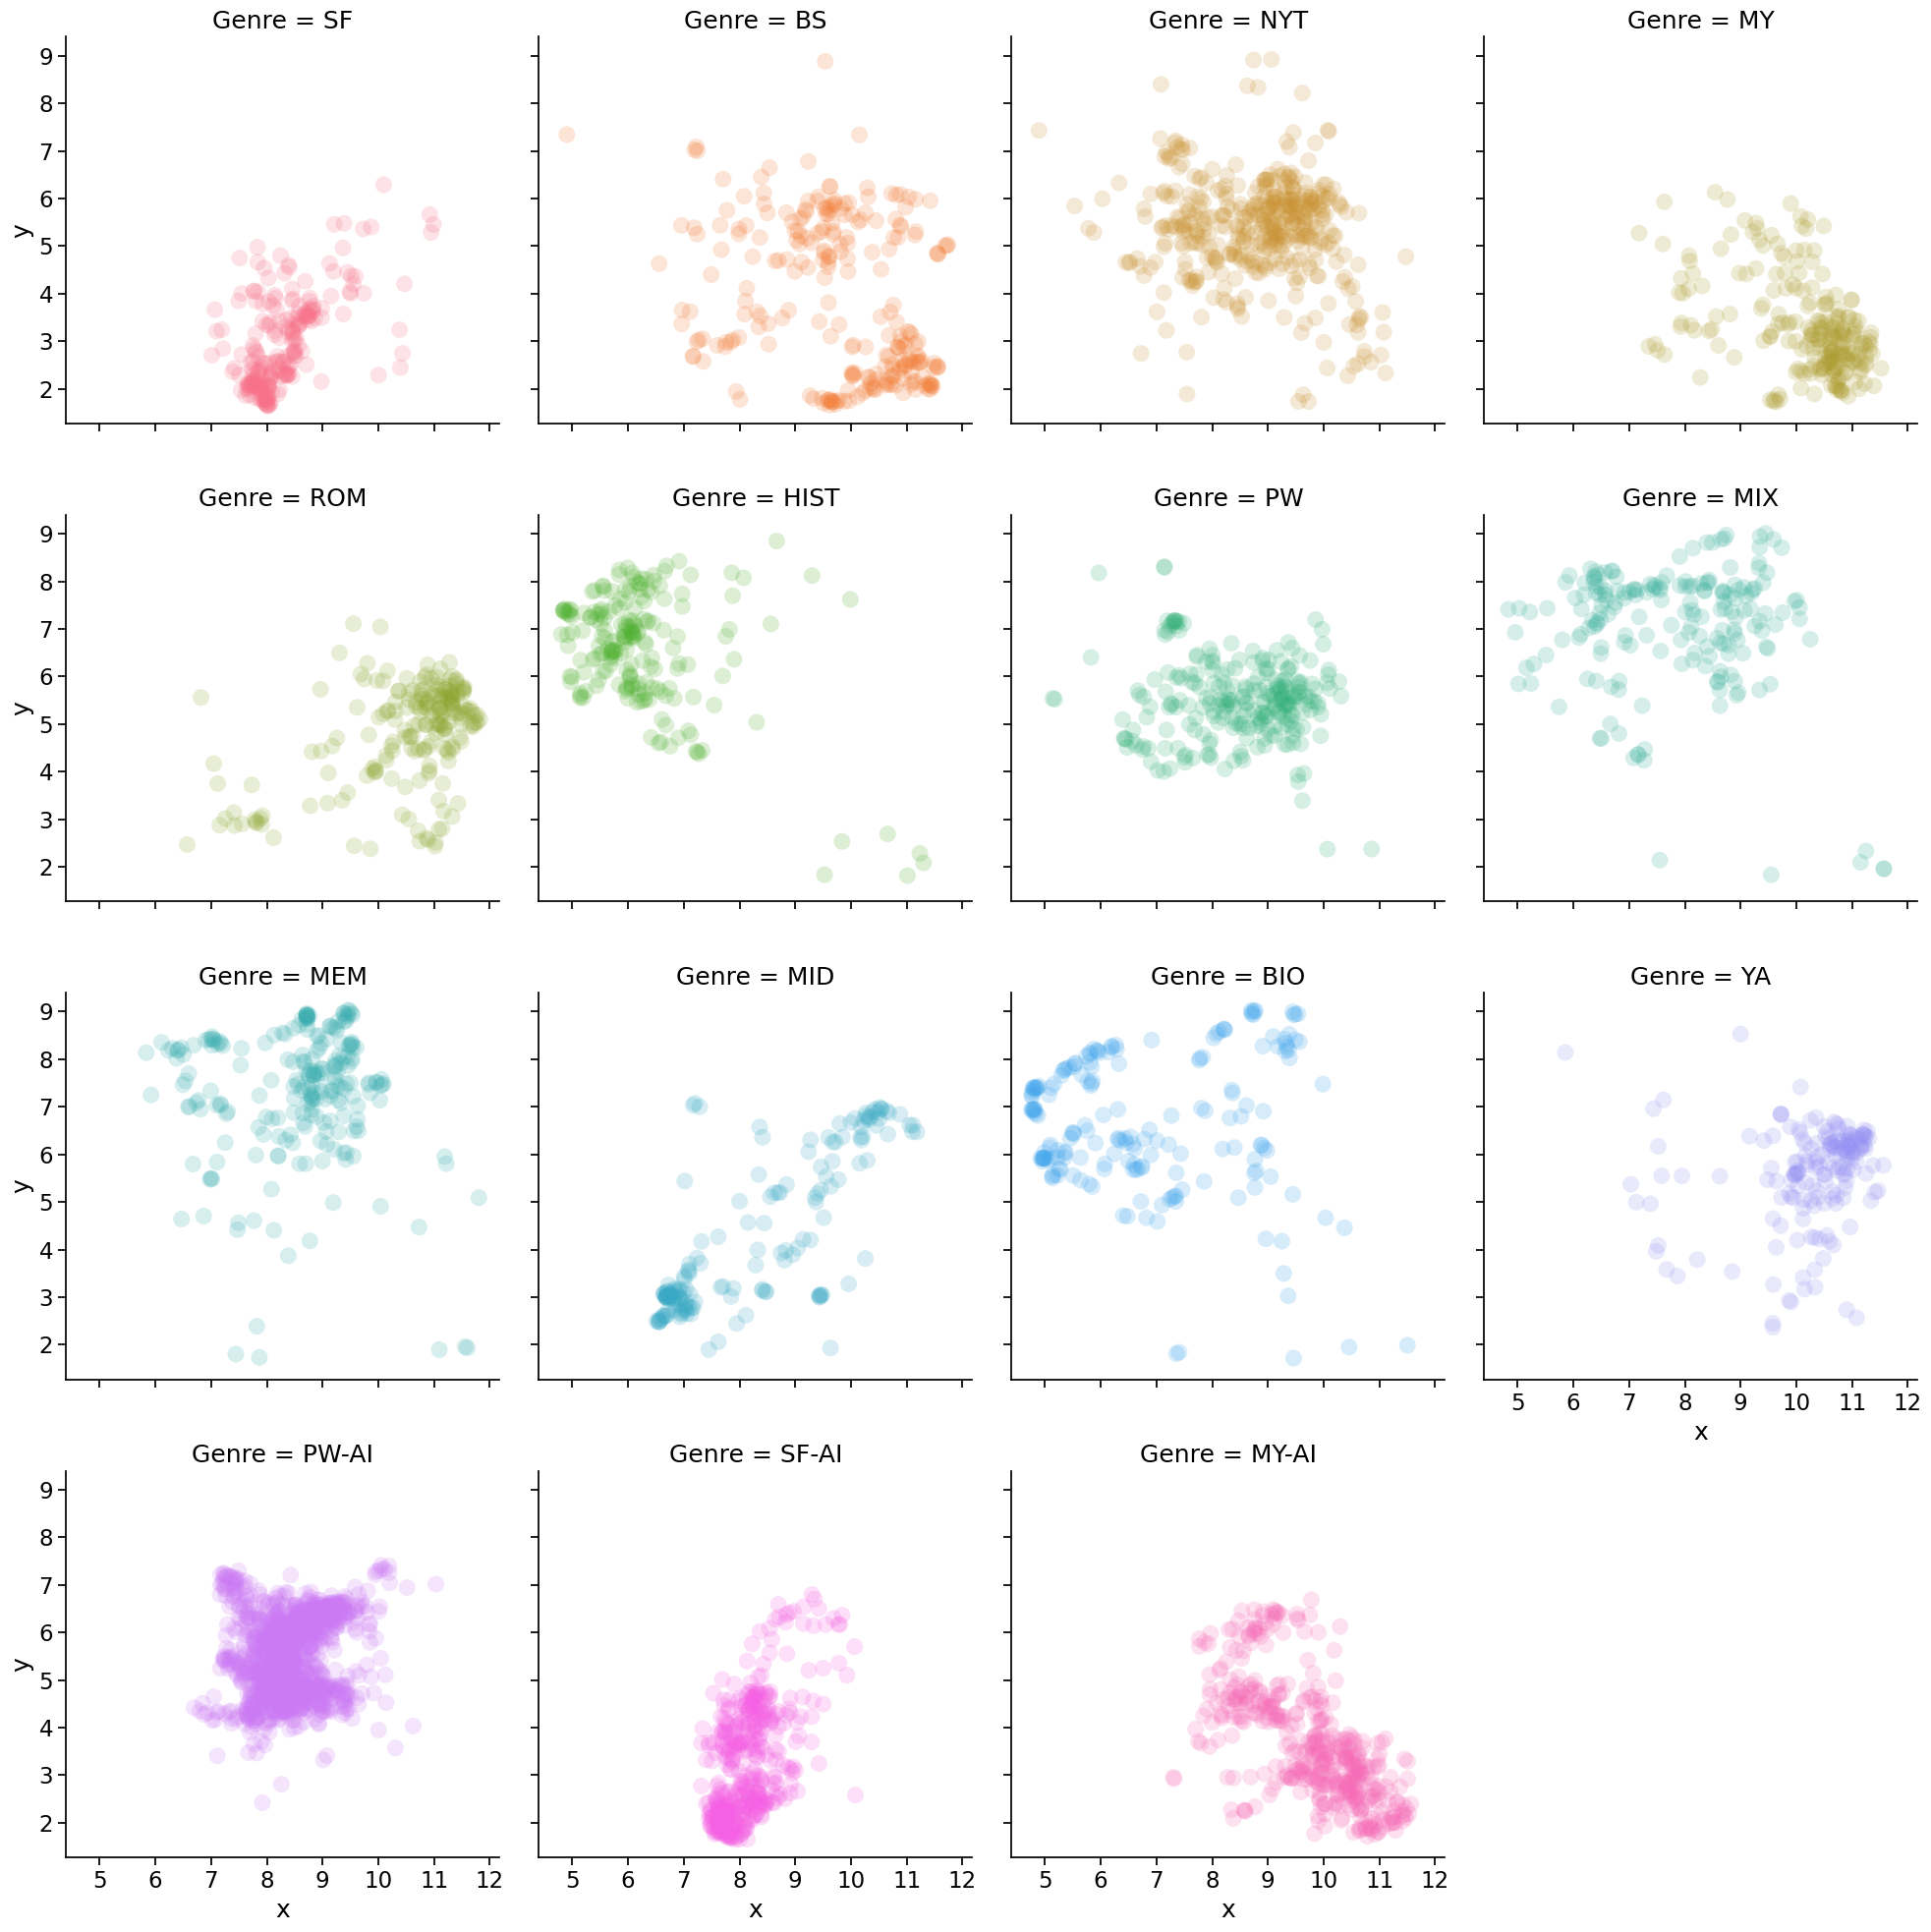

In [16]:
# small multiples
with sns.plotting_context('notebook', font_scale=1.5):
    g = sns.relplot(
        x='x',
        y='y',
        data=plot_data.loc[plot_data['Prompt']!='Basic'],
        hue='Genre',
        col='Genre',
        col_wrap=4,
        kind='scatter',
        alpha=0.2,
        linewidth=0,
        legend=False,
        s=150
    )
    plt.tight_layout()
    plt.savefig('../figures/embeddings_by_genre_faceted.png', dpi=300)

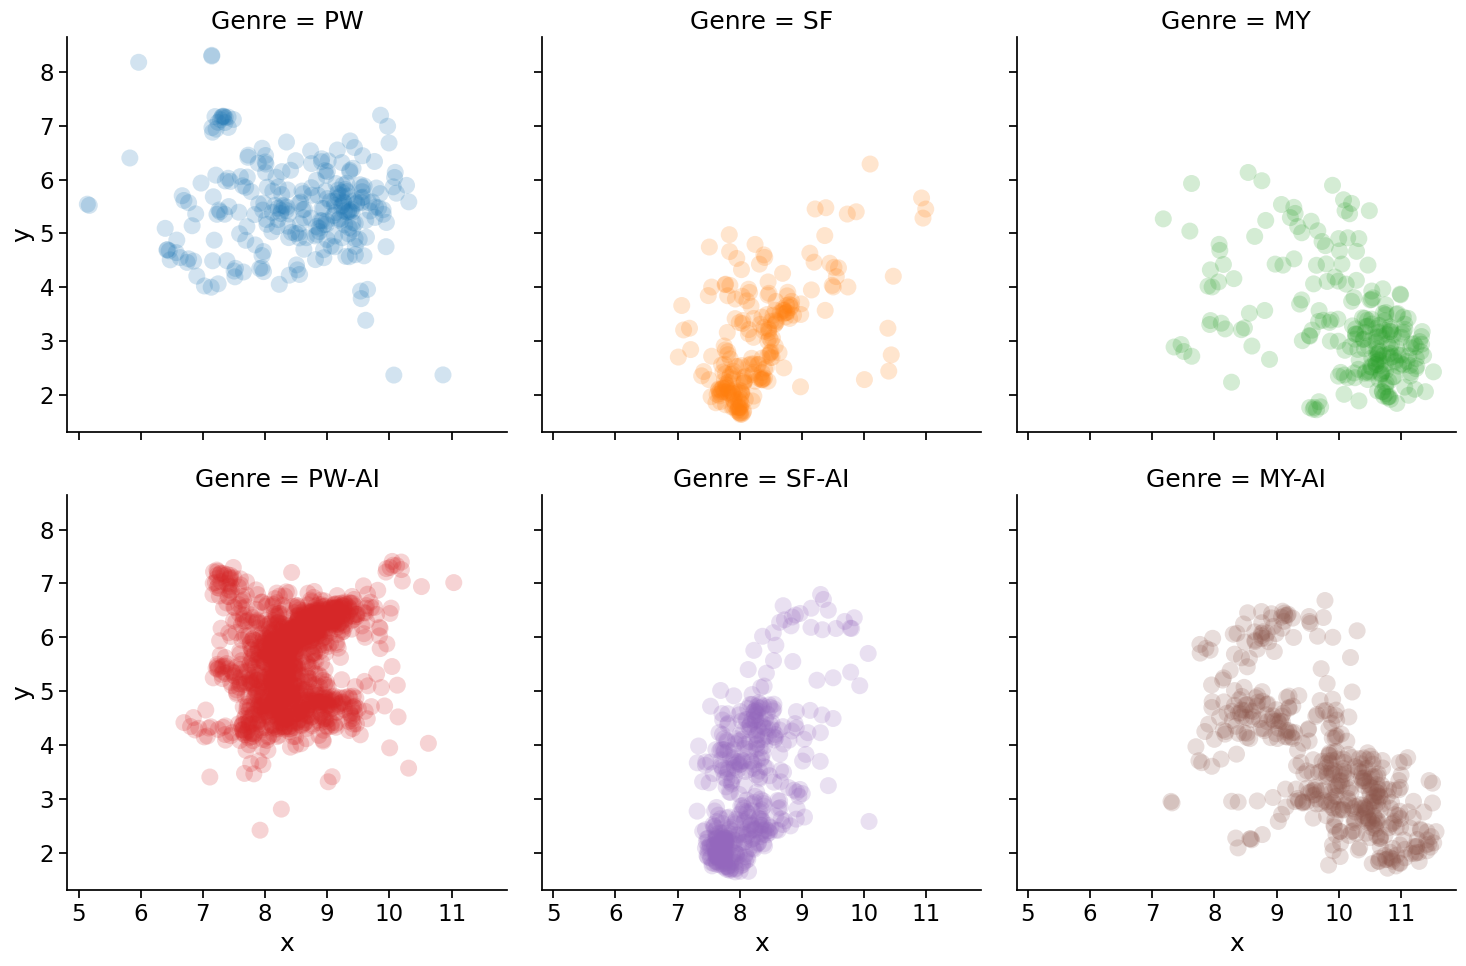

In [17]:
# small multiples, selected
selected_genres = ['PW', 'SF', 'MY', 'PW-AI', 'SF-AI', 'MY-AI']
with sns.plotting_context('notebook', font_scale=1.5):
    g = sns.relplot(
        x='x',
        y='y',
        data=plot_data.loc[
            (plot_data['Genre'].isin(selected_genres)) &
            (plot_data['Prompt']!='Basic')
            ],
        hue='Genre',
        hue_order=selected_genres,
        col='Genre',
        col_order=selected_genres,
        col_wrap=3,
        kind='scatter',
        alpha=0.2,
        linewidth=0,
        legend=False,
        s=150
    )
    plt.tight_layout()
    plt.savefig('../figures/embeddings_by_genre_faceted_selected.png', dpi=300)

In [18]:
# interactive vis
chart = alt.Chart(plot_data).mark_point(
    opacity=0.3, # Set a fixed opacity
    filled=True, # Optional, points are filled by default
    ).encode(
        x='x',
        y='y',
        color='Genre',
        tooltip=[
            'Category', 'Genre', 'Pubdate', 'Author_First_Reviewed',
            'Author_Last_Reviewed', 'Work_Title', 'Prize',
            'Author_Gender', 'Author_Nationality'] # Display these fields in the tooltip on mouseover
).interactive()
chart.save('../figures/embeddings_by_genre_with_gen.html')
chart.display()

alt.Chart(...)

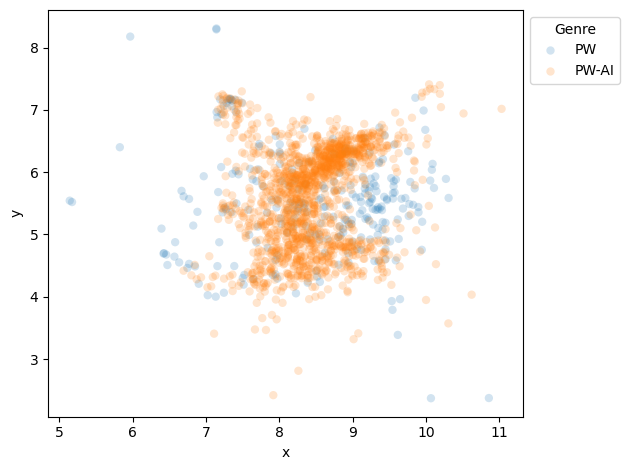

In [19]:
# Just prize genre (real and generated)
# static vis
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[
        (plot_data.Category=='FIC') & \
        ~(plot_data.Prize.isna()) & \
        ~(plot_data.Prompt=='Basic')
        ],
    hue='Genre',
    hue_order=['PW', 'PW-AI'],
    alpha=0.2,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_pw_with_gen.png', dpi=300)

In [20]:
# interactive vis
chart = alt.Chart(plot_data.loc[
        (plot_data.Category=='FIC') & \
        ~(plot_data.Prize.isna()) & \
        ~(plot_data.Prompt=='Basic')
        ]).mark_point(
    opacity=0.3, # Set a fixed opacity
    filled=True, # Optional, points are filled by default
    ).encode(
        x='x',
        y='y',
        color='Genre',
        tooltip=[
            'Category', 'Genre', 'Pubdate', 'Author_First_Reviewed',
            'Author_Last_Reviewed', 'Work_Title', 'Prize',
            'Author_Gender', 'Author_Nationality'] # Display these fields in the tooltip on mouseover
).interactive()
chart.save('../figures/embeddings_pw_with_gen.html')
chart.display()

alt.Chart(...)

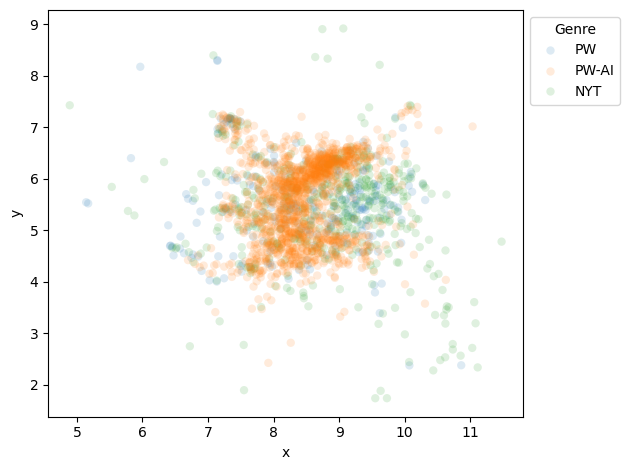

In [21]:
# as above, but with NYT reviewed, too
# static vis
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[
        (plot_data.Category=='FIC') & \
        (plot_data.Genre.isin(['PW-AI','PW','NYT']) & \
        ~(plot_data.Prompt=='Basic'))
        ],
    hue='Genre',
    hue_order=['PW', 'PW-AI', 'NYT'],
    alpha=0.15,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_pw_nyt_with_gen.png', dpi=300)

In [22]:
# interactive vis
chart = alt.Chart(plot_data.loc[
        (plot_data.Category=='FIC') & \
        (plot_data.Genre.isin(['PW-AI','PW','NYT']) & \
        ~(plot_data.Prompt=='Basic'))
        ]).mark_point(
    opacity=0.2, # Set a fixed opacity
    filled=True, # Optional, points are filled by default
    ).encode(
        x='x',
        y='y',
        color=alt.Color('Genre', sort=['PW-AI','PW','NYT']),
        tooltip=[
            'Category', 'Genre', 'Pubdate', 'Author_First_Reviewed',
            'Author_Last_Reviewed', 'Work_Title', 'Prize',
            'Author_Gender', 'Author_Nationality'] # Display these fields in the tooltip on mouseover
).interactive()
chart.save('../figures/embeddings_pw_nyt_with_gen.html')
chart.display()

alt.Chart(...)

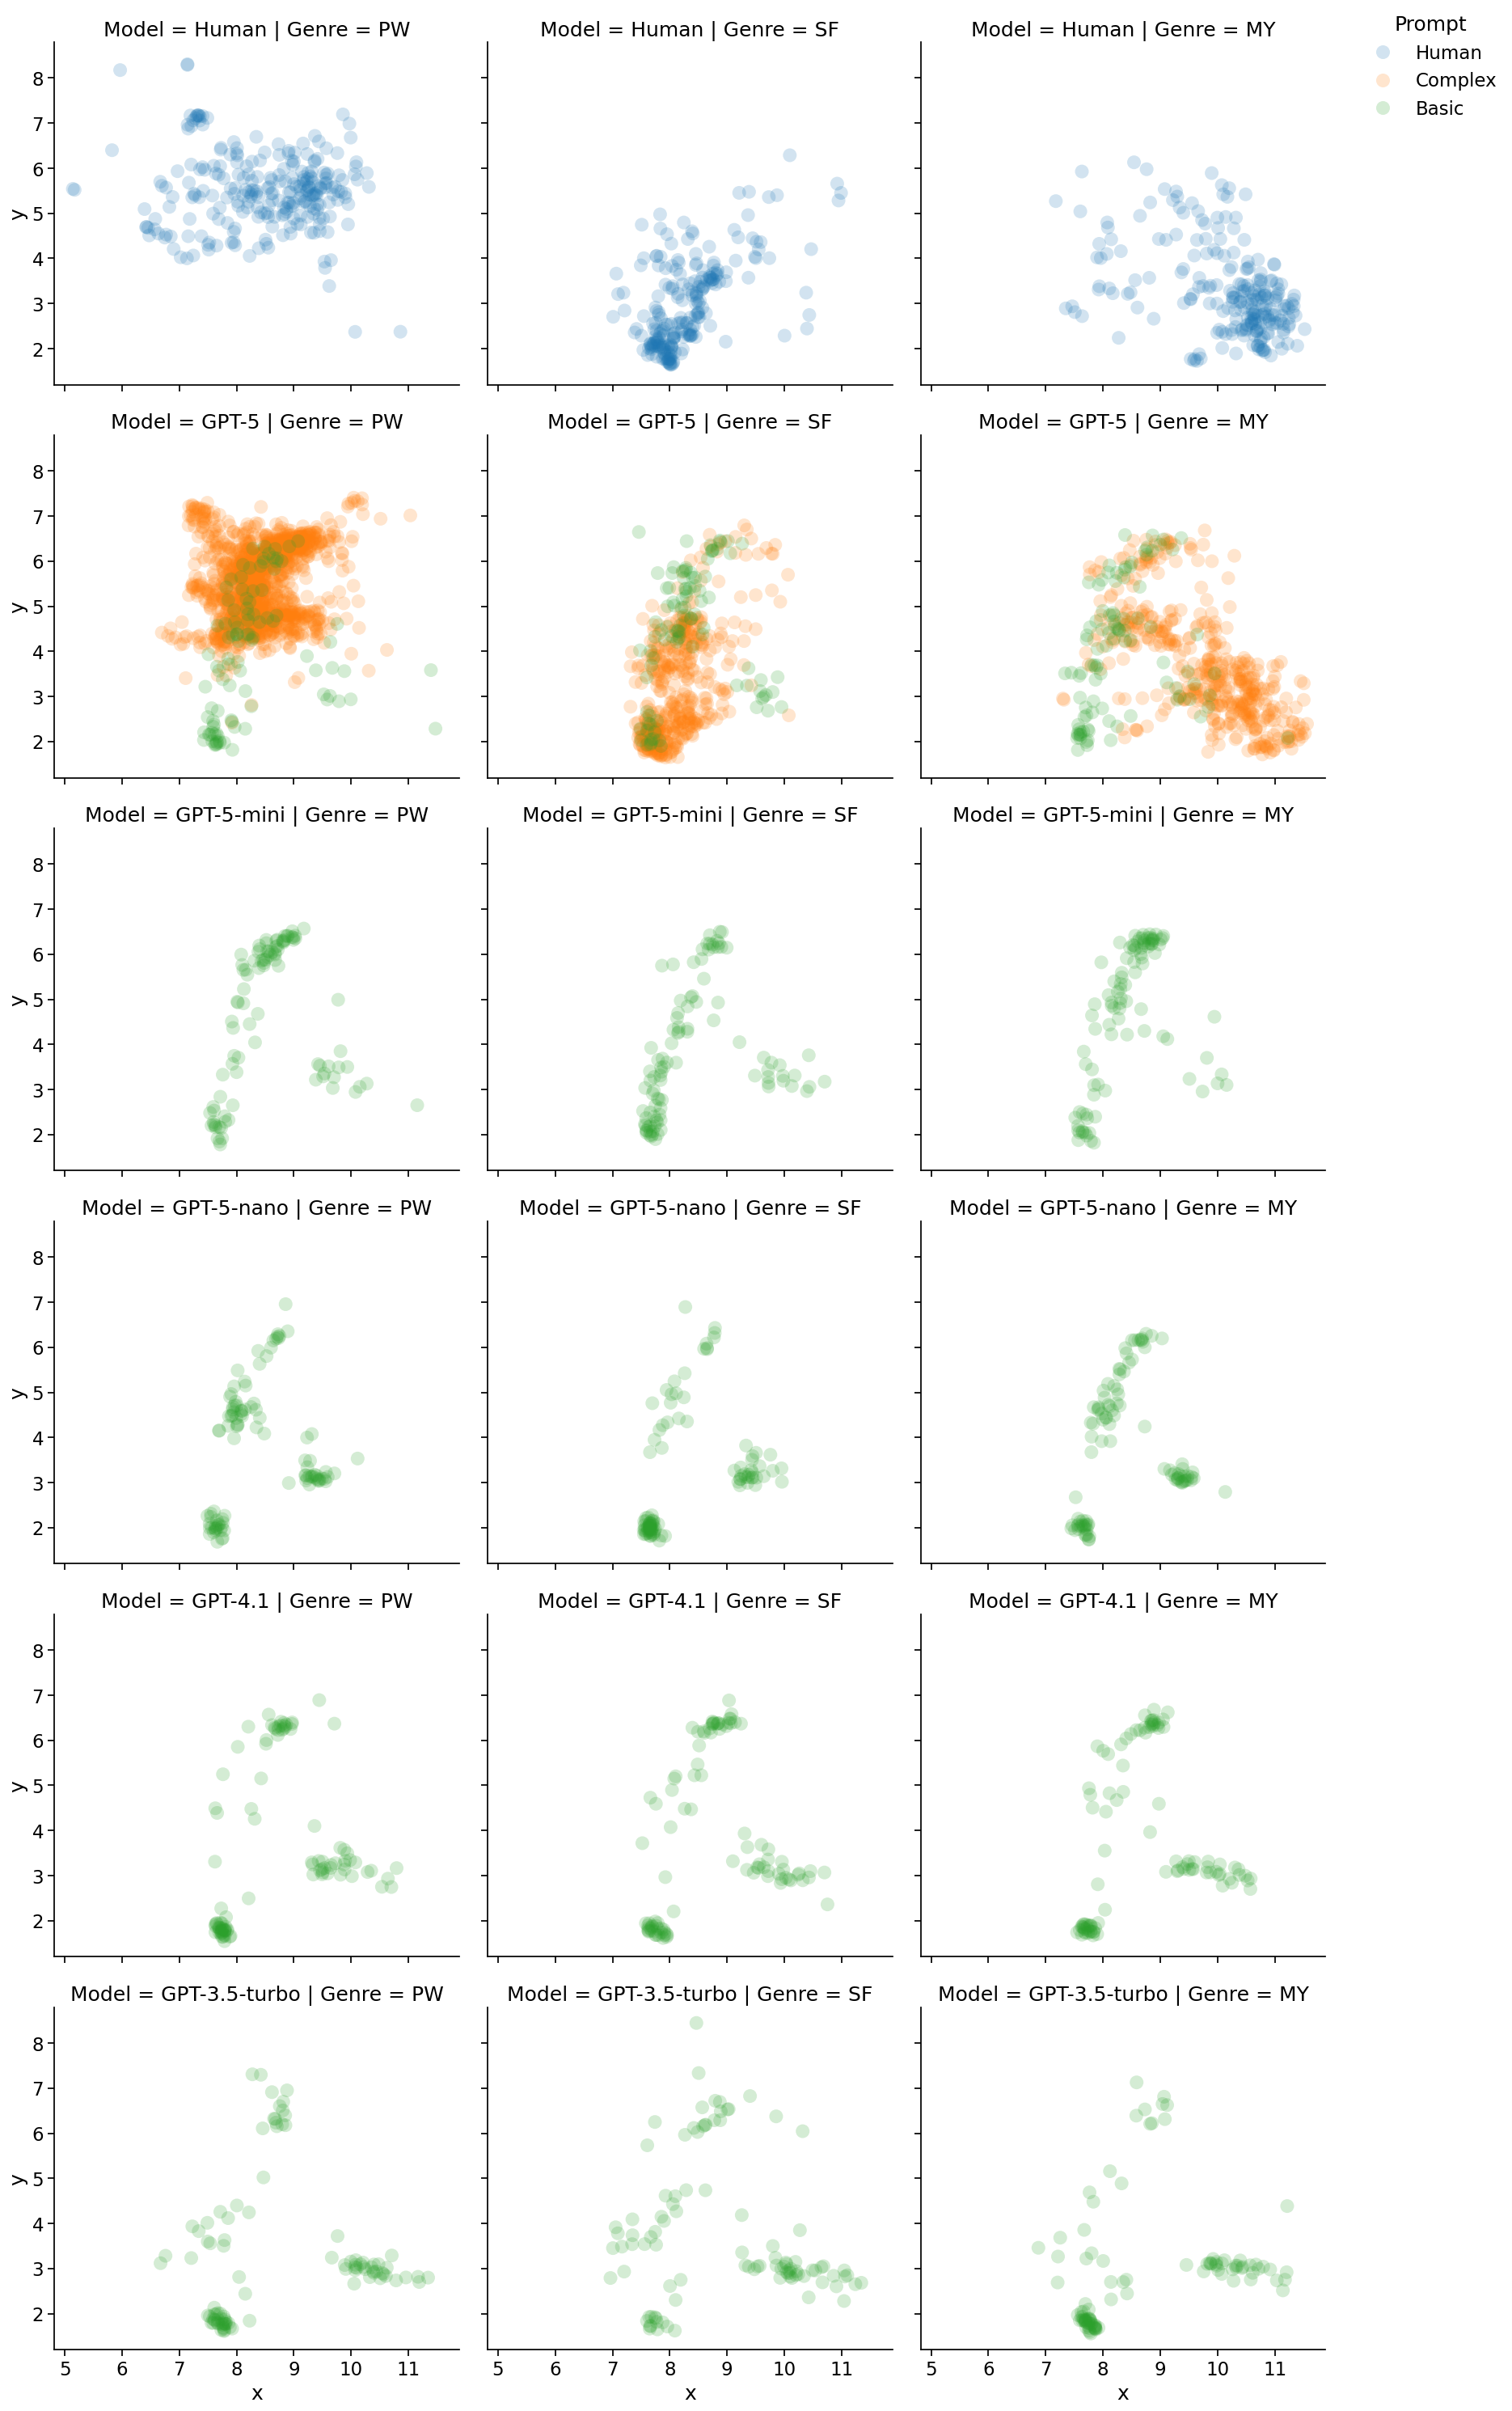

In [23]:
# Compare human to complex and basic prompts
# small multiples, selected
df = plot_data.copy()
df['Genre_original'] = df['Genre']
df['Genre'] = df['Genre'].apply(lambda x: x.split('-')[0])
selected_genres = ['PW', 'SF', 'MY']
with sns.plotting_context('notebook', font_scale=1.5):
    g = sns.relplot(
        x='x',
        y='y',
        data=df.loc[
            (df['Genre'].isin(selected_genres))
            ],
        hue='Prompt',
        col='Genre',
        col_order=selected_genres,
        row='Model',
        kind='scatter',
        alpha=0.2,
        linewidth=0,
        legend=True,
        s=150
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    g.savefig('../figures/embeddings_by_genre_prompts_faceted_selected.png', dpi=300)

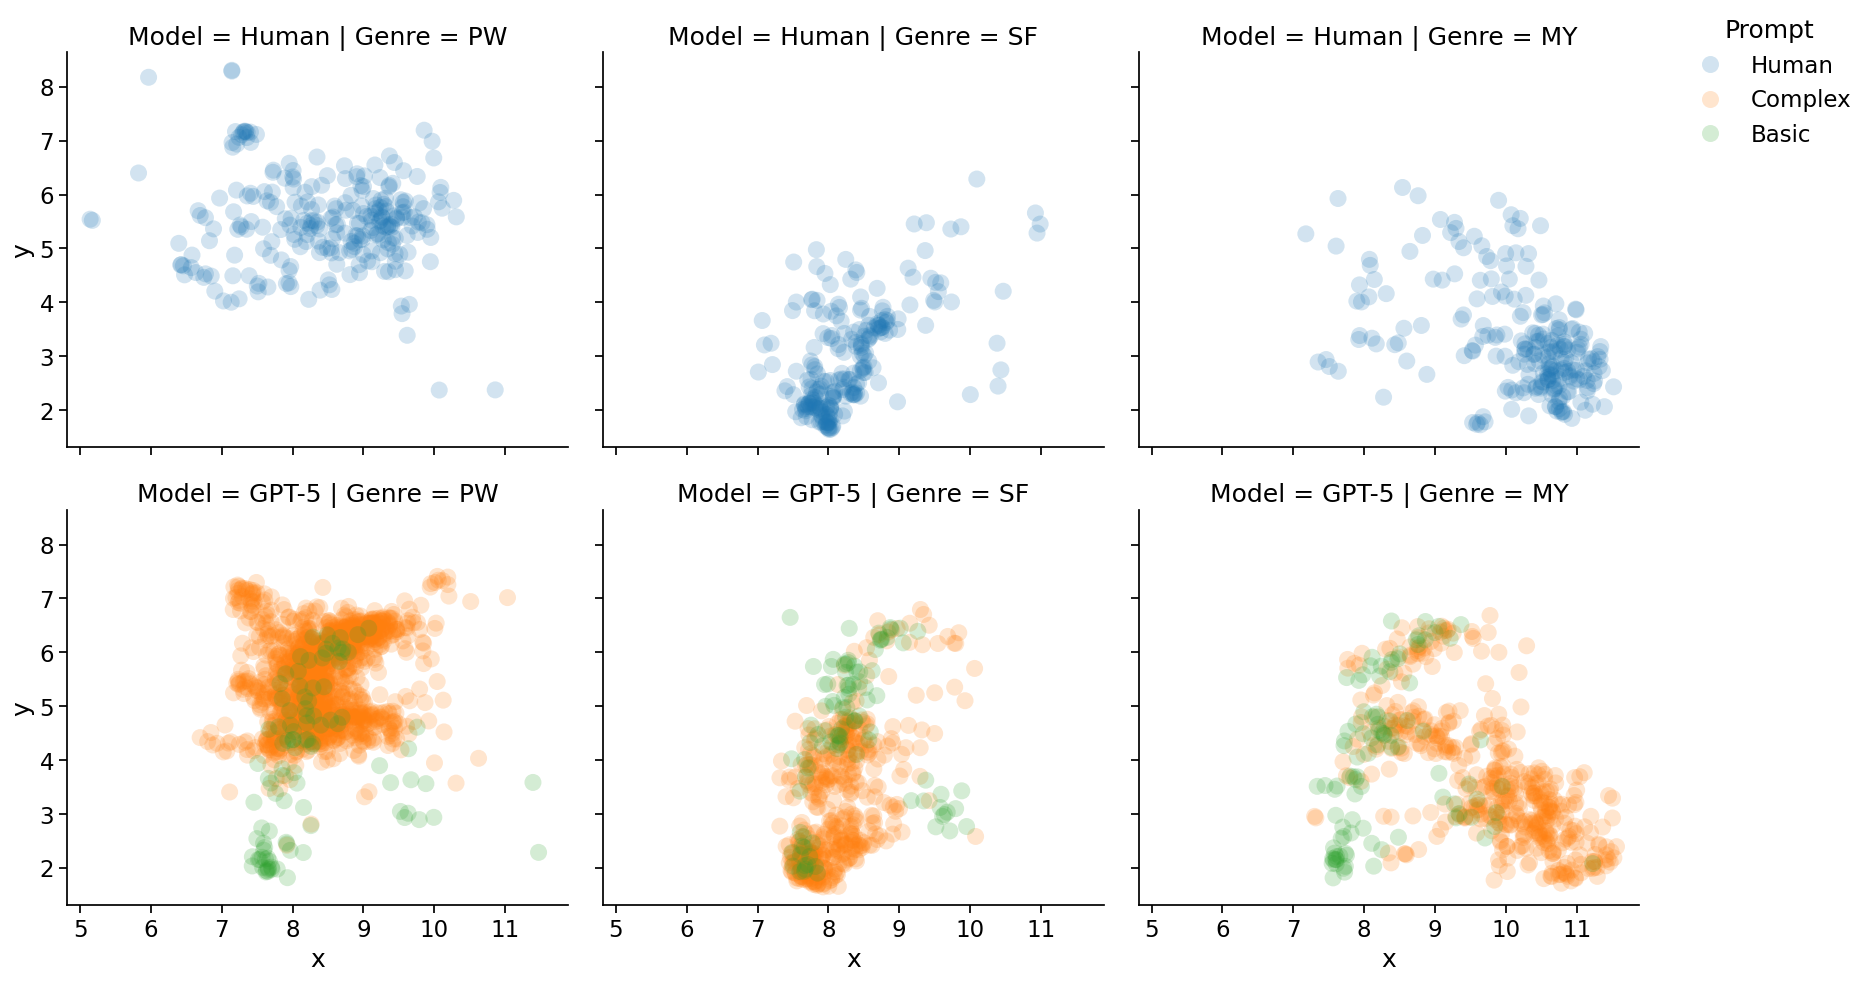

In [24]:
# Ditto, just GPT-5

selected_genres = ['PW', 'SF', 'MY']
with sns.plotting_context('notebook', font_scale=1.5):
    g = sns.relplot(
        x='x',
        y='y',
        data=df.loc[
            (df['Genre'].isin(selected_genres)) &
            (df['Model'].isin(['Human', 'GPT-5']))
            ],
        hue='Prompt',
        col='Genre',
        col_order=selected_genres,
        row='Model',
        kind='scatter',
        alpha=0.2,
        linewidth=0,
        legend=True,
        s=150
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    g.savefig('../figures/embeddings_by_genre_prompts_faceted_selected_gpt5.png', dpi=300)

## Similarities

In [25]:
def group_similarities(column, label, data, meta=meta_all):
    '''Takes a column id, label/value, and dataframe of embeddings.
    Assumes embeddings are normalized. Calculates similarities via dot products.
    Calculates the pairwise similarities of embeddings selected by column and label.
    Returns a 1-D array of non-redundant, off-diagonal similarities.'''
    arr = np.stack(data.loc[meta[column]==label].values)
    sim = np.dot(arr,arr.T)
    return(sim[np.triu_indices_from(sim, k=1)])

### Within-group

In [26]:
# assemble data
emb_all_mean = pd.concat([emb_mean, emb_gen_mean, emb_gen_sf_mean, emb_gen_my_mean])
emb_all_mean_models = pd.concat([emb_gen_model_means[model] for model in models])
emb_all_mean = pd.concat([emb_all_mean, emb_all_mean_models])

In [27]:
# within-group similarities (no AI)
genres = []
means = []
stds = []
genres_to_compare = list(meta_all['Genre'].unique())[:-3] # AI is last; remove it

selector = meta_all['Prompt']!='Basic'

for genre in genres_to_compare:
    sims = group_similarities(
        'Genre', 
        genre, 
        emb_all_mean.loc[selector], 
        meta_all.loc[selector]
    )
    genres.append(genre)
    means.append(sims.mean())
    stds.append(sims.std())
pd.DataFrame.from_dict(
    {
        'Genre':genres,
        'Sim mean':means,
        'Std':stds
    }
).sort_values(by='Sim mean', ascending=False)

,Genre,Sim mean,Std
0,SF,0.652559,0.054778
3,MY,0.647427,0.049660
6,PW,0.635168,0.058703
11,YA,0.631677,0.048293
9,MID,0.628998,0.058063
1,BS,0.616767,0.060999
4,ROM,0.604377,0.045174
2,NYT,0.604375,0.051350
8,MEM,0.547500,0.076597
10,BIO,0.485052,0.071415


In [28]:
# within-group similarities
genres = []
means = []
stds = []
for genre in meta_all['Genre'].unique():
    sims = group_similarities('Genre', genre, emb_all_mean.loc[meta_all.Prompt.isin(['Human','Complex'])], meta_all)
    genres.append(genre)
    means.append(sims.mean())
    stds.append(sims.std())
pd.DataFrame.from_dict(
    {
        'Genre':genres,
        'Sim mean':means,
        'Std':stds
    }
).sort_values(by='Sim mean', ascending=False)

,Genre,Sim mean,Std
0,SF,0.652559,0.054778
3,MY,0.647427,0.049660
6,PW,0.635168,0.058703
11,YA,0.631677,0.048293
9,MID,0.628998,0.058063
1,BS,0.616767,0.060999
14,MY-AI,0.609697,0.048530
4,ROM,0.604377,0.045174
2,NYT,0.604375,0.051350
13,SF-AI,0.600901,0.051228


### Initial chunks and full texts

Real books only, no generations. Needs full embeddings data (slow, c. 10 mins), not just the book-level averages.

In [29]:
if use_all:
    # similarities of short initial chunks to (same) full volumes
    # select and sort full books
    full = np.stack(emb_mean.sort_index().values)
    
    # 2k tokens
    two_k = np.stack(emb.query('seq==0').sort_index()['embed'].values)
    two_k_sim = np.diagonal(np.dot(two_k, full.T))
    print(f'Mean similaritity between first  2k tokens and full book: {two_k_sim.mean().item():.3f} (std {two_k_sim.std().item():.3f})')
    
    # 5k tokens
    five_k = np.stack(emb.query('seq==1').sort_index()['embed'].values)
    five_k_sim = np.diagonal(np.dot(five_k, full.T))
    print(f'Mean similaritity between first  5k tokens and full book: {five_k_sim.mean().item():.3f} (std {five_k_sim.std().item():.3f})')
    
    # 32k tokens (first full chunk)
    t2_k = np.stack(emb.query('seq==2').sort_index()['embed'].values)
    t2_k_sim = np.diagonal(np.dot(t2_k, full.T))
    print(f'Mean similaritity between first 32k tokens and full book: {t2_k_sim.mean().item():.3f} (std {t2_k_sim.std().item():.3f})')

In [30]:
# group pairwise comparisons
def compare_group_similarities(column, labels, data, meta=meta_all):
    '''Compare similarities between groups, testing for stat signif.
    Takes a column, two classes in that column, and a dataframe of embeddings.
    Assumes embeddings are normed and metadata is in a df named 'meta'.
    Returns pairwise mean similarity within groups and between groups, plus 
      t and p values via Welch's t-test.'''
    label1 = labels[0]
    label2 = labels[1]
    arr1 = np.stack(data.loc[meta[column]==label1].values)
    arr2 = np.stack(data.loc[meta[column]==label2].values)
    sim11 = group_similarities(column, label1, data)
    sim22 = group_similarities(column, label2, data)
    sim12 = np.dot(arr1,arr2.T)
    sim12 = sim12[np.triu_indices_from(sim12, k=1)]
    sim21 = np.dot(arr2,arr1.T)
    sim21 = sim21[np.triu_indices_from(sim21, k=1)]
    test12 = stats.ttest_ind(sim11, sim12, equal_var=False)
    test21 = stats.ttest_ind(sim22, sim21, equal_var=False)
    return([[sim11.mean(), sim12.mean(), test12],[sim22.mean(), sim21.mean(), test21]])

def get_significance_label(p_value):
    """
    Returns standard significance labels based on p-value.
    """
    if p_value <= 0.001:
        return "***"
    elif p_value <= 0.01:
        return "**"
    elif p_value <= 0.05:
        return "*"
    else:
        return "" # Not significant

def compare_groups(column, data, meta=meta_all):
    '''Compare all possible pairs of groups.
    Takes a column name and a df of normed embeddings.
    Assumes metadata in df named 'meta'.
    Returns a dataframe of comparisons.'''
    group_comparisons = {
        'Group 1':[],
        'Group 2':[],
        'Self sim avg':[],
        'Other sim avg':[],
        'p value':[]
    }
    for group_pair in combinations(meta[column].dropna().unique(),2):
        result = compare_group_similarities(column, group_pair, data, meta=meta_all)
        group_comparisons['Group 1'].append(group_pair[0])
        group_comparisons['Group 2'].append(group_pair[1])
        group_comparisons['Self sim avg'].append(result[0][0].item())
        group_comparisons['Other sim avg'].append(result[0][1].item())
        group_comparisons['p value'].append(result[0][2].pvalue.item())
        group_comparisons['Group 1'].append(group_pair[1])
        group_comparisons['Group 2'].append(group_pair[0])
        group_comparisons['Self sim avg'].append(result[1][0].item())
        group_comparisons['Other sim avg'].append(result[1][1].item())
        group_comparisons['p value'].append(result[1][2].pvalue.item())


    df = pd.DataFrame.from_dict(group_comparisons)
    df['ind'] = df['p value'].apply(get_significance_label)
    return(df.sort_values(by=['Group 1', 'Group 2']))

### By genres

In [31]:
# compare by genre
selector = meta_all['Prompt']!='Basic'

genre_comps = compare_groups(
    'Genre', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)
genre_comps.loc[genre_comps['p value'] > 0.001]

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
45,BIO,BS,0.485052,0.485861,0.191961,
19,BIO,SF,0.485052,0.485420,0.547477,
30,BS,MY,0.616767,0.618245,0.002309,**


In [32]:
# AI vs ...
genre_comps.loc[genre_comps['Group 1'] == 'PW-AI'].sort_values(by='Other sim avg', ascending=False)

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
206,PW-AI,MY-AI,0.580149,0.561840,0.0,***
204,PW-AI,SF-AI,0.580149,0.545289,0.0,***
149,PW-AI,PW,0.580149,0.544176,0.0,***
73,PW-AI,NYT,0.580149,0.523566,0.0,***
95,PW-AI,MY,0.580149,0.504339,0.0,***
49,PW-AI,BS,0.580149,0.504283,0.0,***
23,PW-AI,SF,0.580149,0.502265,0.0,***
185,PW-AI,MID,0.580149,0.502234,0.0,***
199,PW-AI,YA,0.580149,0.497400,0.0,***
115,PW-AI,ROM,0.580149,0.470649,0.0,***


**NB.** Although AI generations are distinct from all others genres (as is true of nearly all possible genre pairs), they are closest (by quite a lot) to PW.

In [33]:
# PW vs ...
genre_comps.loc[genre_comps['Group 1'] == 'PW'].sort_values(by='Other sim avg', ascending=False)

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
61,PW,NYT,0.635168,0.616830,0.0,***
37,PW,BS,0.635168,0.603412,0.0,***
83,PW,MY,0.635168,0.599205,0.0,***
11,PW,SF,0.635168,0.596014,0.0,***
146,PW,YA,0.635168,0.591917,0.0,***
142,PW,MID,0.635168,0.591123,0.0,***
103,PW,ROM,0.635168,0.575809,0.0,***
140,PW,MEM,0.635168,0.553020,0.0,***
152,PW,MY-AI,0.635168,0.545836,0.0,***
148,PW,PW-AI,0.635168,0.540298,0.0,***


In [34]:
# NYT vs ...
genre_comps.loc[genre_comps['Group 1'] == 'NYT'].sort_values(by='Other sim avg', ascending=False)

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
60,NYT,PW,0.604375,0.620470,0.000000e+00,***
29,NYT,BS,0.604375,0.597317,1.363791e-88,***
54,NYT,MY,0.604375,0.595323,1.180797e-136,***
70,NYT,YA,0.604375,0.588745,1.693071e-277,***
3,NYT,SF,0.604375,0.584423,0.000000e+00,***
66,NYT,MID,0.604375,0.583185,0.000000e+00,***
56,NYT,ROM,0.604375,0.572925,0.000000e+00,***
64,NYT,MEM,0.604375,0.544142,0.000000e+00,***
76,NYT,MY-AI,0.604375,0.536488,0.000000e+00,***
72,NYT,PW-AI,0.604375,0.523506,0.000000e+00,***


In [35]:
print(f'Mean within-genre similarity: {genre_comps['Self sim avg'].mean():.3f}')
print(f'Mean across-genre similarity: {genre_comps['Other sim avg'].mean():.3f}')

Mean within-genre similarity: 0.586
Mean across-genre similarity: 0.514


**NB.** Above result suggests that almost *all* possible genre pairs are unique from one another. Note also that measured similarities between initial 5k tokens and the whole book is *much* higher than in-genre mean similarities. 

### By era

In [36]:
def map_era(x):
    era_map = {
        'Through 2010':[-np.inf,2011],
        '2011 and later':[2011,np.inf],
    }
    if np.isnan(x):
        return('Not specified')
    for key in era_map.keys():
        if era_map[key][0] <= x < era_map[key][1]:
            return(key)
    return('Error')
plot_data['Era'] = plot_data['Pubdate'].map(map_era)

In [37]:
plot_data['Era'].value_counts()

Era
2011 and later    3545
Not specified     1871
Through 2010      1109
Name: count, dtype: int64

In [38]:
# compare by era, prizewinners (only)
#  that is, do we see temporal change in human writing of lit fic?
selector = (meta_all.Category=='FIC') & \
           ~(meta_all.Prize.isna()) & \
           ~(meta_all.Prize == 'AI')
era_comps = compare_groups(
    'Era', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)
era_comps

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
1,2011 and later,Through 2010,0.634787,0.637735,0.001348,**
0,Through 2010,2011 and later,0.636237,0.632379,0.000021,***


In [39]:
# ditto, in NYT
selector = (meta_all.Category=='FIC') & \
           (meta_all.Genre == 'NYT')
era_nyt_comps = compare_groups(
    'Era', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)
era_nyt_comps

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
1,2011 and later,Through 2010,0.604480,0.518899,NaN,
0,Through 2010,2011 and later,0.640954,0.593557,NaN,


In [40]:
# ditto, in BS
selector = (meta_all.Category=='FIC') & \
           (meta_all.Genre == 'BS')
era_bs_comps = compare_groups(
    'Era', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)
era_bs_comps

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
1,2011 and later,Through 2010,0.621697,0.613268,3.016700e-09,***
0,Through 2010,2011 and later,0.610507,0.610595,9.498019e-01,


So, there *very little* change over a decade of time in PW and BS human fiction. Hard to tell the difference between pre-2011 and post-2011. Of course, small samples, and it's all pretty (self-)similar. More evidence of change in NYT, though suspect strong effects of changing selection practices.

How about date-directed vs. date unspecified AI writing?

In [41]:
plot_data['Dated'] = plot_data.Pubdate.apply(
    lambda x: 'Dated' if ~np.isnan(x) else 'Unspecified'
)
plot_data['Dated'].value_counts()

Dated
Dated          4654
Unspecified    1871
Name: count, dtype: int64

In [42]:
# dated v. undated AI generations
selector = (meta_all.Category=='FIC') & \
           ~(meta_all.Prize.isna()) & \
           (meta_all.Prize == 'AI') & \
           (meta_all.Prompt == 'Complex')
dated_comps = compare_groups(
    'Dated', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)
dated_comps

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
0,Dated,Unspecified,0.578515,0.583799,1.963426e-43,***
1,Unspecified,Dated,0.591785,0.584105,2.313358e-78,***


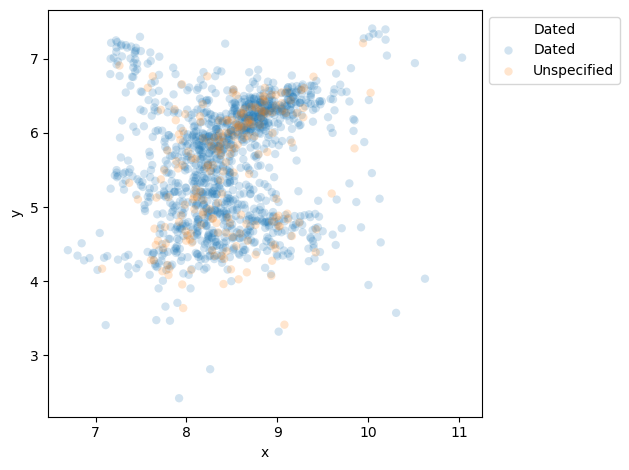

In [43]:
# visualize dated v. undated
# Dated v undated generations
# static vis
ax =sns.scatterplot(
    x='x',
    y='y',
    data=plot_data.loc[selector],
    hue='Dated',
    alpha=0.2,
    linewidth=0
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../figures/embeddings_ai_dated.png', dpi=300)

### By prompt

Just GPT-5 complex v. basic (v. human)

In [44]:
# PW
selector = (meta_all.Category=='FIC') & \
           (meta_all.Genre.isin(['PW', 'PW-AI'])) & \
           (meta_all.Model.isin(['Human', 'GPT-5']))
prompt_comps = compare_groups('Prompt', emb_all_mean[selector], meta_all[selector])
print('Prizewinners')
prompt_comps.sort_values('Self sim avg')

Prizewinners


,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
4,Complex,Basic,0.580149,0.559382,1.274581e-202,***
1,Complex,Human,0.580149,0.544176,0.000000e+00,***
5,Basic,Complex,0.631546,0.571119,0.000000e+00,***
3,Basic,Human,0.631546,0.528168,0.000000e+00,***
2,Human,Basic,0.635168,0.517347,0.000000e+00,***
0,Human,Complex,0.635168,0.540298,0.000000e+00,***


In [45]:
# SF
selector = (meta_all.Category=='FIC') & \
           (meta_all.Genre.isin(['SF', 'SF-AI'])) & \
           (meta_all.Model.isin(['Human', 'GPT-5']))
prompt_comps = compare_groups('Prompt', emb_all_mean[selector], meta_all[selector])
print('SciFi')
prompt_comps.sort_values('Self sim avg')

SciFi


,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
4,Complex,Basic,0.600901,0.576409,3.980687e-191,***
1,Complex,Human,0.600901,0.552806,0.000000e+00,***
5,Basic,Complex,0.626757,0.573821,0.000000e+00,***
3,Basic,Human,0.626757,0.515076,0.000000e+00,***
2,Human,Basic,0.652559,0.526704,0.000000e+00,***
0,Human,Complex,0.652559,0.557434,0.000000e+00,***


In [46]:
# MY
selector = (meta_all.Category=='FIC') & \
           (meta_all.Genre.isin(['MY', 'MY-AI'])) & \
           (meta_all.Model.isin(['Human', 'GPT-5']))
prompt_comps = compare_groups('Prompt', emb_all_mean[selector], meta_all[selector])
print('Mystery')
prompt_comps.sort_values('Self sim avg')

Mystery


,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
4,Complex,Basic,0.609697,0.558342,0.0,***
1,Complex,Human,0.609697,0.562908,0.0,***
5,Basic,Complex,0.634645,0.578783,0.0,***
3,Basic,Human,0.634645,0.509228,0.0,***
2,Human,Basic,0.647427,0.506323,0.0,***
0,Human,Complex,0.647427,0.571441,0.0,***


## Bios and unmasking

This is a step toward understanding the parts of the prompting strategy that influence performance. Begin by looking into bios. How many bios can be "deanonymized" by an LLM? How similar are the generated fictions for a given bio to the real books by the same author? Is this last number different for those authors/bios that can be deanonymized?

### Identify generated bios

In [47]:
# author bio unmasking
author_bio_unmask = pd.read_csv(
    '../results/predicted_author_bios.csv'
)
author_bio_unmask['fict_bio'] = author_bio_unmask['fict_bio'].apply(str.strip)

# Add missing entry
author_bio_unmask.loc[len(author_bio_unmask)] = [
    "Karan Mahajan",
    """You were born in 1983 in New Delhi, where the layered histories of the city shaped your early imagination. After studying literature and political science in the United States, you began to write fiction that explored the contradictions of modern India—its rapid growth alongside persistent dislocation. Your first novel, published to considerable acclaim, was praised for its intricate structure and its unsparing portrayal of family life amid political unrest. Critics have noted your sharp, restless prose and your ability to move between satire and empathy. For this debut, you received the Whiting Award, marking you as a significant new voice.""",
    "Aatish Taseer",
    0
]

In [48]:
print(f"Fraction of generated bios that are unmaskable: {np.round(author_bio_unmask.match.sum()/len(author_bio_unmask),3)}")

Fraction of generated bios that are unmaskable: 0.652


In [49]:
# prompt bios
chapter_prompts = pd.read_json(
    '../prompts/complex/chapters_prompts_pw.jsonl',
    lines=True
)['body']
def select_bio(item):
    return(item['input'].split('\n')[0][len('Personal context: '):].strip())
chapter_prompts = chapter_prompts.apply(select_bio)

In [50]:
# merge data on bio text
merged_bios = author_bio_unmask.merge(chapter_prompts, how='right', left_on='fict_bio', right_on='body').drop(columns=['fict_bio', 'body', 'pred_author'])
merged_bios.sample(5)

,original_author,match
549,Joseph Boyden,1
478,Rabih Alameddine,1
518,Elizabeth Tallent,1
268,Hisham Matar,1
53,Joshua Ferris,1


In [51]:
print(f"Fraction of generated texts with unmaskable bios: {np.round(merged_bios.match.sum()/len(merged_bios),3)}")

Fraction of generated texts with unmaskable bios: 0.642


### Match generated bios to embeddings

In [52]:
# add kludgey original_author field for matching
meta_all['original_author'] = meta_all.loc[meta_all['Genre']=='PW', 'Author_First_Reviewed'] + ' ' + meta_all.loc[meta_all['Genre']=='PW', 'Author_Last_Reviewed']

In [53]:
# set match values for human text
unmaskable = merged_bios.drop_duplicates().set_index('original_author')
unmaskable.loc['Ben Fountain'] = 1
temp = meta_all.loc[~meta_all.original_author.isna(), ['original_author']].merge(unmaskable, left_on='original_author', right_index=True, how='left')
meta_all.loc[temp.index, 'match'] = temp['match']
del temp

In [54]:
# set match values for generated texts
merged_bios.index = [f'pw-{i}.tsv' for i in merged_bios.index]
meta_all.loc[merged_bios.index, ['original_author', 'match']] = merged_bios[['original_author','match']]

In [55]:
meta_all.loc[~meta_all['original_author'].isna()]

,x,y,Category,Language,Genre,Genre2,Pubdate,Author_Last,Author_First,Author_First_Reviewed,...,goodreads_avg,total_ratings,goodreads_URL,Probability1P,Prompt,Model,Era,Dated,original_author,match
"2005_Banville,John_TheSea_PW.txt",9.221381,5.700469,FIC,English,PW,NaN,2005.0,Banville,John,John,...,3.53,29397.0,https://www.goodreads.com/search?q=John+Banvil...,1.0,Human,Human,Through 2010,Dated,John Banville,1.0
"2005_Barfoot,Joan_Luck_PW.txt",9.469676,5.549514,FIC,English,PW,NaN,2005.0,Barfoot,Joan,Joan,...,3.17,426.0,https://www.goodreads.com/search?q=Joan+Barfoo...,0.0,Human,Human,Through 2010,Dated,Joan Barfoot,0.0
"2005_Barnes,Julian_ArthurGeorge_PW.txt",9.617851,3.387796,FIC,English,PW,NaN,2005.0,Barnes,Julian,Julian,...,3.72,17242.0,https://www.goodreads.com/search?q=Julian+Barn...,0.0,Human,Human,Through 2010,Dated,Julian Barnes,1.0
"2005_Barry,Sebastian_LongLongWay_PW.txt",7.590219,4.993467,FIC,English,PW,NaN,2005.0,Barry,Sebastian,Sebastian,...,4.11,7083.0,https://www.goodreads.com/search?q=Sebastian+B...,0.0,Human,Human,Through 2010,Dated,Sebastian Barry,1.0
"2005_Bergen,David_TheTimeinBetween_PW.txt",8.614264,5.737170,FIC,English,PW,NaN,2005.0,Bergen,David,David,...,4.15,36289.0,https://www.goodreads.com/search?q=+The+Timein...,0.0,Human,Human,Through 2010,Dated,David Bergen,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pw-1395.tsv,7.574441,6.609350,FIC,English,PW-AI,NaN,NaN,NaN,NaN,GPT-5,...,NaN,NaN,NaN,NaN,Complex,GPT-5,Not specified,Unspecified,Phil Klay,1.0
pw-1396.tsv,8.749084,5.954543,FIC,English,PW-AI,NaN,NaN,NaN,NaN,GPT-5,...,NaN,NaN,NaN,NaN,Complex,GPT-5,Not specified,Unspecified,Colin McAdam,0.0
pw-1397.tsv,8.538944,6.074202,FIC,English,PW-AI,NaN,NaN,NaN,NaN,GPT-5,...,NaN,NaN,NaN,NaN,Complex,GPT-5,Not specified,Unspecified,Pascale Quiviger,0.0
pw-1398.tsv,9.147532,6.439732,FIC,English,PW-AI,NaN,NaN,NaN,NaN,GPT-5,...,NaN,NaN,NaN,NaN,Complex,GPT-5,Not specified,Unspecified,Annie Dillard,1.0


### Bio comparisons

Many ways we could slice the bio analysis. A few to try:

1. **Mean similarity of PW to PW-AI (unmaskable) vs. PW-AI (not unmaskable).** Expectation: Texts generated from unmaskable bios will be more similar to real PW texts than are those generated from non-unmaskable bios.
2. **Mean similarity of PW books by the same author.** That is, how similar are an author's books to one another. Expect this to be high, and a reasonable upper bound to the similarity of generated texts from unmaskable bios to those by the source author.
3. **Ditto, but for multiple generated texts from the same bio (unmaskable or not).**
4. **Mean similarity across real v. unmaskable-bio-generated texts for each unmaskable author.** That is, e.g., Colson Whitehead books v. texts generated from Colson Whitehead's bio. Compare this to the previous numbers.

#### Big picture: unmaskable v. not

In [56]:
# compare unmaskable PW to unmaskable AI
selector = meta_all['match']==1.0

compare_groups(
    'Genre', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
0,PW,PW-AI,0.635682,0.541361,0.0,***
1,PW-AI,PW,0.581111,0.544379,0.0,***


In [57]:
# compare NON unmaskable PW to NON unmaskable AI
selector = meta_all['match']==0.0

compare_groups(
    'Genre', 
    emb_all_mean.loc[selector], 
    meta_all.loc[selector]
)

,Group 1,Group 2,Self sim avg,Other sim avg,p value,ind
0,PW,PW-AI,0.635423,0.539619,0.0,***
1,PW-AI,PW,0.580197,0.545397,0.0,***


#### By author

In [58]:
# all bios, matched
ai_self_sims = []
ai_author_sims = []
weights = []

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for author in meta_all.loc[
        (meta_all.Genre=='PW-AI') &\
        (~meta_all.original_author.isna()),
        'original_author'].unique():
    
        selector = (~meta_all['match'].isna()) & \
                   (meta_all['original_author']==author)
    
        out = compare_groups(
            'Genre', 
            emb_all_mean.loc[selector], 
            meta_all.loc[selector]
        )
        ai_self_sims.append(out.at[1, 'Self sim avg'])
        ai_author_sims.append(out.at[0, 'Other sim avg'])
        weights.append(len(meta_all.loc[selector]) - 1)

In [59]:
print(f"Mean AI self-similarity (same bio): {round(np.nanmean(ai_self_sims),3)}")
print(f"Mean AI similarity to matching author: {round(np.nanmean(ai_author_sims),3)}")

Mean AI self-similarity (same bio): 0.716
Mean AI similarity to matching author: 0.602


In [60]:
# just those that are unmaskable
ai_self_sims = []
ai_author_sims = []
weights = []

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for author in meta_all.loc[
        (meta_all.Genre=='PW-AI') &\
        (~meta_all.original_author.isna()),
        'original_author'].unique():
    
        selector = (meta_all['match']==1.0) & \
                   (meta_all['original_author']==author)
    
        out = compare_groups(
            'Genre', 
            emb_all_mean.loc[selector], 
            meta_all.loc[selector]
        )
        try: 
            ai_self_sims.append(out.at[1, 'Self sim avg'])
            ai_author_sims.append(out.at[0, 'Other sim avg'])
            weights.append(len(meta_all.loc[selector]) - 1)
        except KeyError:
            continue
print(f"Mean AI self-similarity (same bio, unmaskable): {round(np.nanmean(ai_self_sims),3)}")
print(f"Mean AI similarity to matching unmskable author: {round(np.nanmean(ai_author_sims),3)}")

Mean AI self-similarity (same bio, unmaskable): 0.722
Mean AI similarity to matching unmskable author: 0.605


In [61]:
# just those that are NOT unmaskable
ai_self_sims = []
ai_author_sims = []
weights = []

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for author in meta_all.loc[
        (meta_all.Genre=='PW-AI') &\
        (~meta_all.original_author.isna()),
        'original_author'].unique():
    
        selector = (meta_all['match']==0.0) & \
                   (meta_all['original_author']==author)
    
        out = compare_groups(
            'Genre', 
            emb_all_mean.loc[selector], 
            meta_all.loc[selector]
        )
        try: 
            ai_self_sims.append(out.at[1, 'Self sim avg'])
            ai_author_sims.append(out.at[0, 'Other sim avg'])
            weights.append(len(meta_all.loc[selector]) - 1)
        except KeyError:
            continue
print(f"Mean AI self-similarity (same bio, NOT unmaskable): {round(np.nanmean(ai_self_sims),3)}")
print(f"Mean AI similarity to matching NON-unmaskable author: {round(np.nanmean(ai_author_sims),3)}")

Mean AI self-similarity (same bio, NOT unmaskable): 0.704
Mean AI similarity to matching NON-unmaskable author: 0.595
